<a href="https://colab.research.google.com/github/marcdaveon345-cell/Data-Science-Lab-Work/blob/main/Lab6_KNN_Classification/Lab6_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Standard Scaler
from sklearn.preprocessing import StandardScaler

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

# Performance Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report

In [13]:
import numpy as np
import pandas as pd

In [14]:
df_train = pd.read_csv("/content/train_KNN.csv")
df_test = pd.read_csv("/content/test_KNN.csv")

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [17]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [19]:
mp = mp[mp > 0].sort_values()
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [20]:
df_train["Age"].median()

28.0

In [21]:
df_train["Fare"].median()

14.4542

In [22]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [23]:
df_train = df_train.dropna(axis=0, subset=["Embarked"])

In [24]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [25]:
df_train = df_train.drop(["Cabin"], axis=1)

In [26]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [27]:
mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [28]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test["Fare"] = df_test["Fare"].fillna(df_test["Fare"].median())
df_test = df_test.drop(["Cabin"], axis=1)

In [29]:
df_train = pd.get_dummies(df_train, columns=["Sex","Embarked"], drop_first=True)
df_test = pd.get_dummies(df_test, columns=["Sex","Embarked"], drop_first=True)

In [30]:
X_train = df_train.drop(["Survived", "Name", "Ticket", "PassengerId"], axis=1)
y_train = df_train["Survived"]

X_test = df_test.drop(["Name", "Ticket", "PassengerId", "Survived"], axis=1)

In [31]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [33]:
y_pred = knn.predict(X_train)

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report

print("Accuracy:", accuracy_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))
print(classification_report(y_train, y_pred))

Accuracy: 0.8571428571428571
Precision: 0.8380952380952381
[[498  51]
 [ 76 264]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       549
           1       0.84      0.78      0.81       340

    accuracy                           0.86       889
   macro avg       0.85      0.84      0.85       889
weighted avg       0.86      0.86      0.86       889



In [36]:
df_train.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [37]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_male    889 non-null    bool   
 7   Embarked_Q  889 non-null    bool   
 8   Embarked_S  889 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 51.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    418 non-null    int64  
 1   Pclass      418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  

In [38]:
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)
df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [40]:
df_train = pd.get_dummies(df_train, columns=["Pclass"], drop_first=True)
df_test = pd.get_dummies(df_test, columns=["Pclass"], drop_first=True)

In [41]:
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

In [42]:
X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]

X_test = df_test.drop("Survived", axis=1)
y_test = df_test["Survived"]

In [43]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [44]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [45]:
y_pred = knn.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="1"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8133971291866029
Precision: 0.7055555555555556
[[213  53]
 [ 25 127]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.85       266
           1       0.71      0.84      0.77       152

    accuracy                           0.81       418
   macro avg       0.80      0.82      0.81       418
weighted avg       0.83      0.81      0.82       418



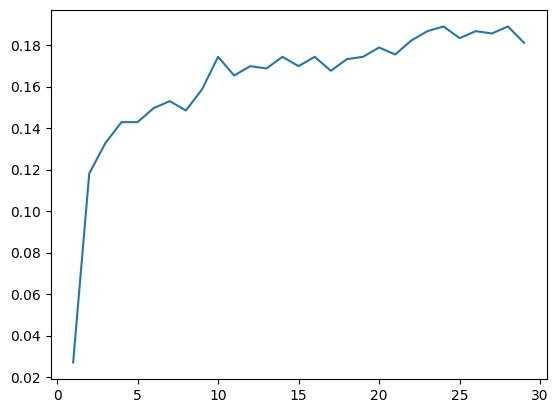

In [48]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

Performance_Metric = []
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    Performance_Metric.append(1 - accuracy_score(y_train, y_pred))

plt.plot(range(1,30), Performance_Metric)